<a href="https://colab.research.google.com/github/cdmafAdi/computer_vision_lecture_notes/blob/main/chp_no-3%20image_vision/L_7_with_finetunning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
    "flower_photos",
    origin=dataset_url,
    untar=True
)

print(data_dir)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
/root/.keras/datasets/flower_photos


In [ ]:


IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3

CLASS_NAMES = ["daisy", "dandelion", "roses", "sunflowers", "tulips"]

In [ ]:
o_data_dir = '/root/.keras/datasets/flower_photos/flower_photos'
train_ds = tf.keras.utils.image_dataset_from_directory(
    o_data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32,
)


Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    o_data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128,128),
    batch_size=32,
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [ ]:
for image_batch, label_batch in train_ds.take(3):
    print("Image batch shape:", image_batch.shape)
    print("Label batch shape:", label_batch.shape)
    print("Labels:", label_batch.numpy())

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
Labels: [2 1 4 3 1 2 1 2 4 1 4 4 3 4 1 2 0 4 1 1 1 4 3 2 3 1 4 2 2 3 4 3]
Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
Labels: [0 2 4 4 4 1 1 1 1 1 3 0 1 2 4 0 3 1 0 0 4 4 4 2 4 1 1 0 4 3 2 0]
Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
Labels: [4 0 2 4 1 2 2 4 0 0 1 3 4 3 4 4 4 3 0 3 4 3 0 0 1 2 0 1 1 4 1 1]


# step 1: loading a pretrained model

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape = (128,128,3),
    include_top = False, # remove classification head
    weights = 'imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# 2 frezee base model

In [ ]:
base_model.trainable = True

**3. adding new calssification head**

In [ ]:
model = tf.keras.Sequential([
            base_model,
            tf.keras.layers.GlobalAveragePooling2D(),
            tf.keras.layers.BatchNormalization(),       # Add BatchNorm
            tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax")
        ])


# regularizer = tf.keras.regularizers.l1_l2(0,0.0001)

# model = tf.keras.Sequential([
#     tf.keras.layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH,IMG_CHANNELS)),
#     tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=regularizer),
#     tf.keras.layers.BatchNormalization(),
#     tf.keras.layers.Dropout(0.5),


#     tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax", kernel_regularizer=regularizer),
#     tf.keras.layers.BatchNormalization()
# ])

In [ ]:
model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
            loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
            metrics=["accuracy"]
        )

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,509 (8.66 MB)

 Trainable params: 2,232,837 (8.52 MB)

 Non-trainable params: 36,672 (143.25 KB)

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=True, to_file="model_visualization.png")
callbacks=[
          tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True,monitor='val_loss')
      ]



In [ ]:
from IPython.core import history

history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=10,
            callbacks=[
              tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True,monitor='val_loss')
          ]
        )

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 114s 611ms/step - accuracy: 0.3985 - loss: 1.5551 - val_accuracy: 0.3978 - val_loss: 1.5578
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.6955 - loss: 0.8383 - val_accuracy: 0.5341 - val_loss: 1.3080
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.7824 - loss: 0.6126 - val_accuracy: 0.6158 - val_loss: 1.0995
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.8375 - loss: 0.4750 - val_accuracy: 0.6676 - val_loss: 0.9677
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.8641 - loss: 0.3834 - val_accuracy: 0.6989 - val_loss: 0.8404
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.8937 - loss: 0.3212 - val_accuracy: 0.7411 - val_loss: 0.7354
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.9063 - loss: 0.2777 - val_accuracy: 0.7575 - val_loss: 0.6300
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.9230 - loss: 0.2465 - val_accuracy: 0.7888

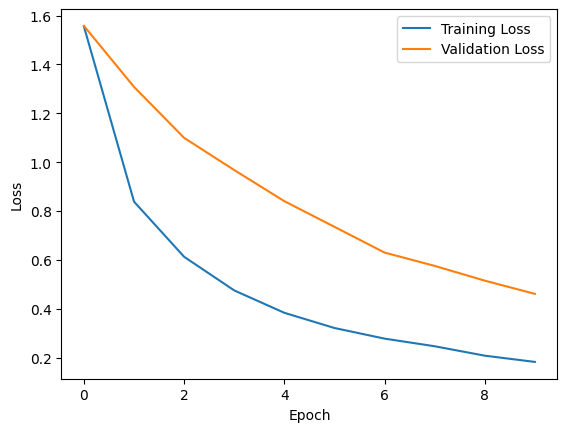

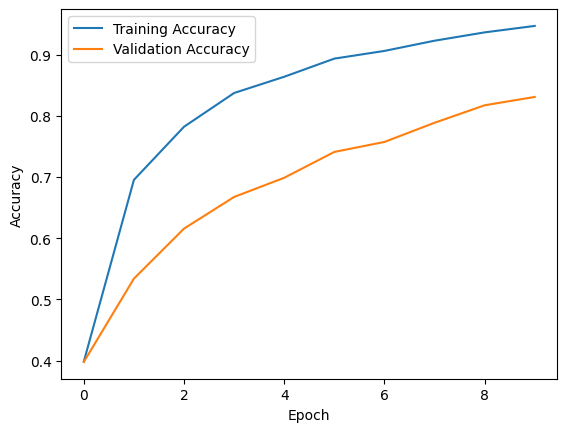

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

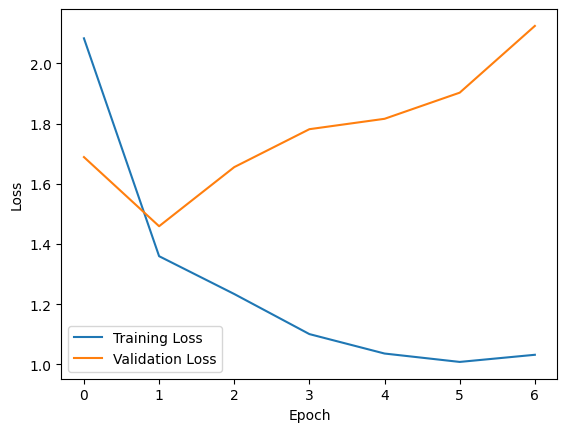

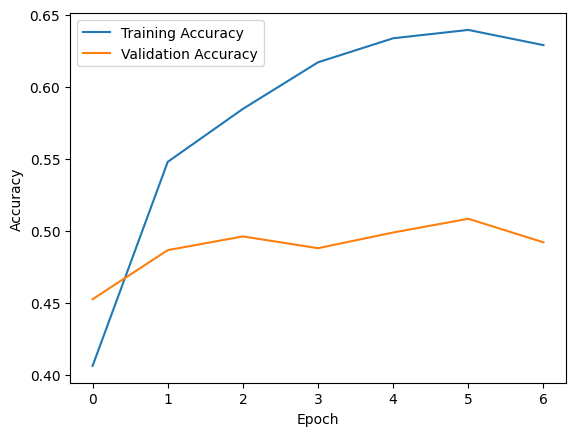

In [ ]:


import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()